In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder, FunctionTransformer,StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

In [2]:
original_df=pd.read_csv("test_df_with_usd_login.csv")

In [3]:
df=original_df.drop("jobma_catcher_id", axis=1)

In [4]:
df.shape

(4462, 15)

In [5]:
df.columns

Index(['company_size', 'is_premium', 'subscription_status',
       'jobma_catcher_status', 'sub_users', 'wallet_amount', 'is_unlimited',
       'plan_type', 'subscription_count', 'invitations',
       'pre_recorded_kit_counts', 'number_of_jobs_posted',
       'pre_rec_interview_taken', 'subscription_amount_usd',
       'days_since_login'],
      dtype='object')

In [6]:
df.isna().sum()

company_size               0
is_premium                 0
subscription_status        0
jobma_catcher_status       0
sub_users                  0
wallet_amount              0
is_unlimited               0
plan_type                  0
subscription_count         0
invitations                0
pre_recorded_kit_counts    0
number_of_jobs_posted      0
pre_rec_interview_taken    0
subscription_amount_usd    0
days_since_login           0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4462 entries, 0 to 4461
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   company_size             4462 non-null   object 
 1   is_premium               4462 non-null   int64  
 2   subscription_status      4462 non-null   int64  
 3   jobma_catcher_status     4462 non-null   int64  
 4   sub_users                4462 non-null   int64  
 5   wallet_amount            4462 non-null   float64
 6   is_unlimited             4462 non-null   int64  
 7   plan_type                4462 non-null   int64  
 8   subscription_count       4462 non-null   int64  
 9   invitations              4462 non-null   int64  
 10  pre_recorded_kit_counts  4462 non-null   int64  
 11  number_of_jobs_posted    4462 non-null   int64  
 12  pre_rec_interview_taken  4462 non-null   int64  
 13  subscription_amount_usd  4462 non-null   float64
 14  days_since_login        

In [8]:
df

,company_size,is_premium,subscription_status,jobma_catcher_status,sub_users,wallet_amount,is_unlimited,plan_type,subscription_count,invitations,pre_recorded_kit_counts,number_of_jobs_posted,pre_rec_interview_taken,subscription_amount_usd,days_since_login
0,1-25,0,1,1,1,66666.0,1,0,1,4,2,1,1,176.5,376
1,1-25,0,1,1,1,66666.0,1,0,1,4,2,1,1,176.5,417
2,26-100,0,2,1,0,60.0,0,1,1,0,0,0,0,0.6,438
3,101-500,0,2,1,0,60.0,0,1,1,0,0,0,0,1.4,438
4,26-100,0,1,1,0,50.0,0,1,3,0,0,1,0,178.8,438
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4457,1-25,0,1,1,0,35.0,0,0,1,3,1,2,3,1.2,328
4458,1-25,0,1,1,0,147.0,0,0,1,3,3,5,1,0.0,328
4459,26-100,0,1,1,0,50.0,0,0,1,0,0,0,0,1.2,327
4460,1-25,0,1,1,0,49.0,0,0,1,2,2,2,1,0.0,326


In [9]:
binary_columns = ['is_premium',
                  'subscription_status',
                  'jobma_catcher_status',
                  'is_unlimited',
                  'plan_type',
                 ]

categorical_columns = ['company_size']
                   
numerical_columns= ['sub_users',
                    'wallet_amount',
                    'subscription_count',
                    'invitations',
                    'pre_recorded_kit_counts',
                    'number_of_jobs_posted',
                    'pre_rec_interview_taken',
                   'days_since_login']

ordinal_columns =['subscription_amount_usd']

In [10]:
# Clean binary values , # Remove negatives and  clamp to 0
def log_transform(X):
    X = X.copy()
    X[X <= 0] = 1e-10
    return np.log(X)

def clean_binary(X):
    return X.apply(lambda col: col.map(lambda val: 1 if pd.to_numeric(val, errors='coerce') > 0 else 0).astype(int))

def clean_categorical(X):
    return X.apply(lambda col: col.map(lambda val: str(val).strip().lower() if pd.notnull(val) else 'others'))

def clean_numerical(X):
    return X.apply(lambda col: pd.to_numeric(col, errors='coerce'))

def clean_ordinal(X):
    return X.apply(lambda col: pd.to_numeric(col, errors='coerce')).clip(lower=0)
    

In [11]:
# Binary pipeline
binary_pipeline = Pipeline(steps=[('cleaner', FunctionTransformer(clean_binary, validate=False)),
                                  ('imputer', SimpleImputer(strategy='most_frequent')),
                                 ])

categorical_pipeline = Pipeline(steps=[('cleaner', FunctionTransformer(clean_categorical, validate=False)),
                                       ('imputer', SimpleImputer(strategy='most_frequent')),
                                       ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
                                      ])

ordinal_pipeline = Pipeline(steps=[('cleaner', FunctionTransformer(clean_ordinal, validate=False)),
                                   ('imputer', SimpleImputer(strategy='median')),
                                   ('log_transform', FunctionTransformer(lambda x: np.log1p(x), validate=False)),
                                  ])

numerical_pipeline = Pipeline(steps=[('cleaner', FunctionTransformer(clean_numerical, validate=False)),
                                     ('imputer', SimpleImputer(strategy='mean')),
                                    ])

preprocessor = ColumnTransformer(transformers=[('bin', binary_pipeline, binary_columns),
                                               ('cat', categorical_pipeline, categorical_columns), 
                                               ('ord', ordinal_pipeline, ordinal_columns),
                                               ('num', numerical_pipeline, numerical_columns),
                                              ])

# Final pipeline
pipeline = Pipeline([('preprocessing', preprocessor),
                    ('scaler', StandardScaler())])

In [12]:
# pipeline

In [13]:
X = pipeline.fit_transform(df)
X_tensor = torch.tensor(X, dtype=torch.float32)
X_tensor.shape

torch.Size([4462, 19])

In [14]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32)
        )

        self.decoder = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim)
        )

    def forward(self, x):
        embeddings = self.encoder(x)
        reconstructed = self.decoder(embeddings)
        return reconstructed, embeddings

In [15]:
input_dim = X_tensor.shape[1]
model = Autoencoder(input_dim)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 20
batch_size = 16

In [16]:
loss_history = []
test_loss_history = []

for epoch in range(epochs):
    epoch_loss = 0.0
    for i in range(0, len(X_tensor), batch_size):
        x_batch = X_tensor[i:i + batch_size]

        optimizer.zero_grad()
        reconstructed, _ = model(x_batch)
        
        loss = criterion(reconstructed, x_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / (len(X_tensor) / batch_size)
    loss_history.append(avg_loss)

    if (epoch + 1) % 2 == 0:
        print(f'Epoch {epoch + 1}/{epochs}, Loss: {loss.item():.4f}')

Epoch 2/20, Loss: 0.0591
Epoch 4/20, Loss: 0.0469
Epoch 6/20, Loss: 0.0461
Epoch 8/20, Loss: 0.0511
Epoch 10/20, Loss: 0.0614
Epoch 12/20, Loss: 0.0598
Epoch 14/20, Loss: 0.0402
Epoch 16/20, Loss: 0.0383
Epoch 18/20, Loss: 0.0318
Epoch 20/20, Loss: 0.0205


In [17]:
#Extract embeddings and # Convert embeddings to numpy array
with torch.no_grad():
    _, embeddings = model(X_tensor)
embeddings_np = embeddings.numpy()
embeddings_np.shape

(4462, 32)

In [18]:
type(embeddings_np), embeddings.shape

(numpy.ndarray, torch.Size([4462, 32]))

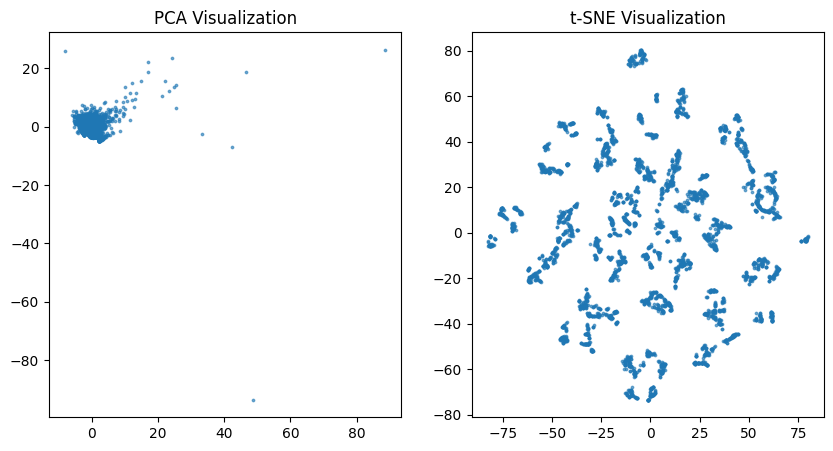

In [19]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(embeddings_np)
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_result = tsne.fit_transform(embeddings_np)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.scatter(pca_result[:, 0], pca_result[:, 1], s=3, alpha=0.6)
plt.title('PCA Visualization')
plt.subplot(1, 2, 2)
plt.scatter(tsne_result[:, 0], tsne_result[:, 1], s=3, alpha=0.6)
plt.title('t-SNE Visualization')
plt.show()

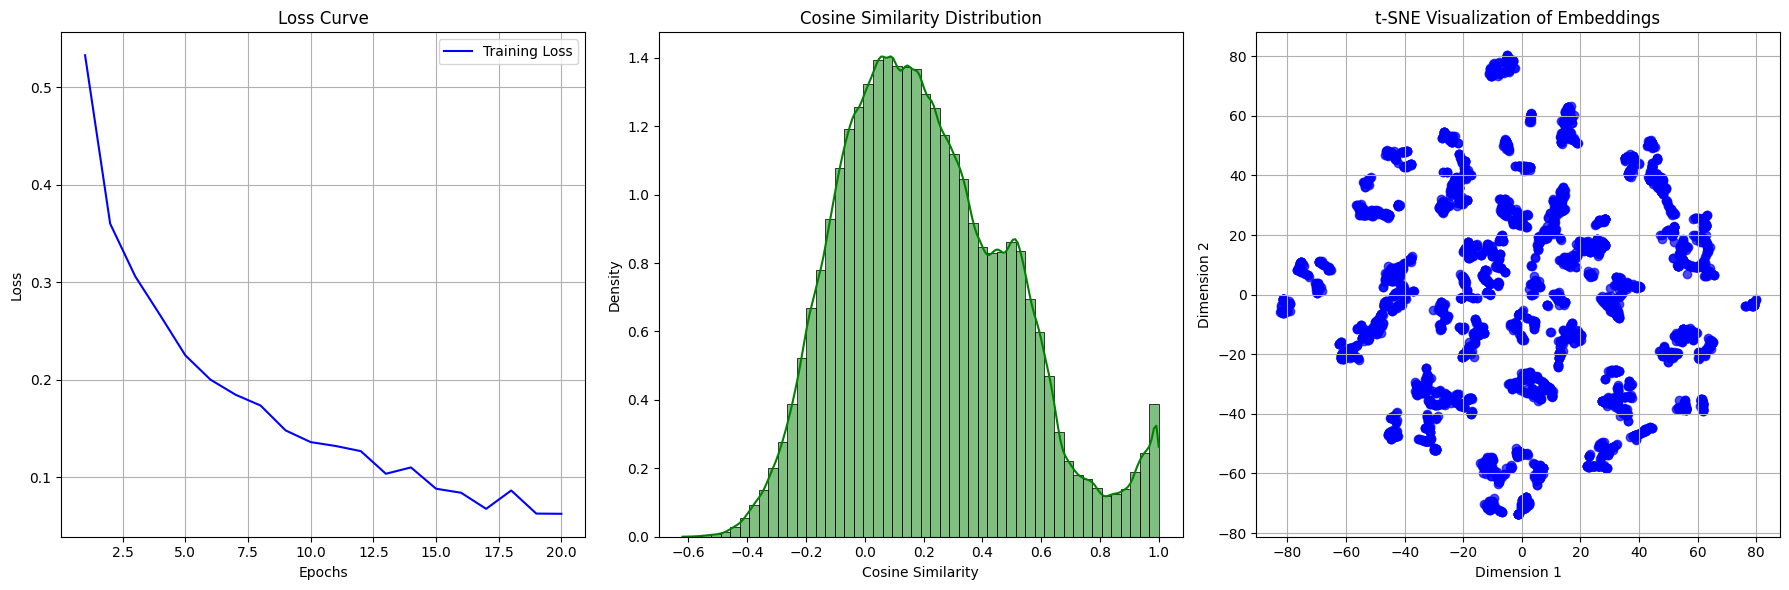

In [20]:
from sklearn.manifold import TSNE
# 1. Plotting the Loss Curve  # 2. Cosine Similarity Distribution  # 3. t-SNE Visualization
fig, axs = plt.subplots(1, 3, figsize=(18, 6))
axs[0].plot(range(1, epochs + 1), loss_history, label='Training Loss', color='blue')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].set_title('Loss Curve')
axs[0].grid(True)
axs[0].legend()

similarities = cosine_similarity(embeddings_np)
sim_scores = similarities[np.triu_indices_from(similarities, k=1)]
sns.histplot(sim_scores, bins=50, kde=True, color='green', stat='density', ax=axs[1])
axs[1].set_title('Cosine Similarity Distribution')
axs[1].set_xlabel('Cosine Similarity')
axs[1].set_ylabel('Density')

tsne = TSNE(n_components=2, random_state=42)
embeddings_2d = tsne.fit_transform(embeddings_np)
axs[2].scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c='blue', alpha=0.7)
axs[2].set_title('t-SNE Visualization of Embeddings')
axs[2].set_xlabel('Dimension 1')
axs[2].set_ylabel('Dimension 2')
axs[2].grid(True)

plt.tight_layout()
plt.show()

# Similarity

In [21]:
def recommend_from_sample_dict(sample_dict, full_embeddings, original_df, pipeline, model, top_n=5):
    sample_df = pd.DataFrame([sample_dict])
    transformed = pipeline.transform(sample_df)
    sample_tensor = torch.tensor(transformed, dtype=torch.float32)
    model.eval()
    with torch.no_grad():
        _, sample_embedding = model(sample_tensor)
    similarities = cosine_similarity(sample_embedding, full_embeddings)[0]
    top_indices = np.argsort(similarities)[::-1][:top_n]
    result_df = original_df.iloc[top_indices].copy()
    result_df['similarity_score'] = similarities[top_indices]
    result_df.reset_index(drop=True, inplace=True)
    return result_df

In [22]:
df.max()

company_size               More than 1000
is_premium                              1
subscription_status                     2
jobma_catcher_status                    1
sub_users                              40
wallet_amount                   4995968.0
is_unlimited                            1
plan_type                               1
subscription_count                    116
invitations                         50046
pre_recorded_kit_counts               292
number_of_jobs_posted                 189
pre_rec_interview_taken               635
subscription_amount_usd         1398501.6
days_since_login                     1793
dtype: object

In [23]:
sample_dict={'company_size': '1-25',
             'is_premium': 0,
             'subscription_status': 1,
             'jobma_catcher_status': 1,
             'sub_users': 0,
             'wallet_amount': 50.0,
             'is_unlimited': 0,
             'plan_type': 0,
             'subscription_count': 1,
             'invitations': 0,
             'pre_recorded_kit_counts': 2,
             'number_of_jobs_posted': 2,
             'pre_rec_interview_taken': 1,
             'subscription_amount_usd': 176.2,
            'days_since_login':376 }

In [24]:
recommend_from_sample_dict(sample_dict, embeddings_np, original_df, pipeline, model, top_n=5)

,jobma_catcher_id,company_size,is_premium,subscription_status,jobma_catcher_status,sub_users,wallet_amount,is_unlimited,plan_type,subscription_count,invitations,pre_recorded_kit_counts,number_of_jobs_posted,pre_rec_interview_taken,subscription_amount_usd,days_since_login,similarity_score
0,10185,1-25,0,2,1,0,50.0,0,0,3,0,1,0,0,118.8,446,0.934635
1,9990,1-25,0,1,1,0,150000.0,0,0,1,2,1,1,0,176.5,538,0.916816
2,5474,1-25,0,2,1,0,60.0,0,0,1,0,0,0,0,176.5,1345,0.915811
3,5584,1-25,0,2,1,0,60.0,0,0,1,0,0,0,0,117.6,1348,0.903324
4,7437,1-25,0,2,1,0,60.0,0,0,3,0,0,0,0,49.5,700,0.902192


In [31]:
sample_dict2 = { 'company_size': '101-500',
                 'is_premium': 0,
                 'subscription_status': 2,
                 'jobma_catcher_status': 1,
                 'sub_users': 0,
                 'wallet_amount': 70,
                 'is_unlimited': 0,
                 'plan_type': 0,
                 'subscription_count': 10,
                 'invitations': 25,
                 'pre_recorded_kit_counts': 3,
                 'number_of_jobs_posted': 5,
                 'pre_rec_interview_taken': 14,
                 'subscription_amount_usd': 118.8,
                 'days_since_login': 1086}

In [32]:
recommend_from_sample_dict(sample_dict2, embeddings_np, original_df, pipeline, model, top_n=5)

,jobma_catcher_id,company_size,is_premium,subscription_status,jobma_catcher_status,sub_users,wallet_amount,is_unlimited,plan_type,subscription_count,invitations,pre_recorded_kit_counts,number_of_jobs_posted,pre_rec_interview_taken,subscription_amount_usd,days_since_login,similarity_score
0,8135,101-500,0,1,1,0,60.0,0,0,7,0,0,0,0,71.4,987,0.931647
1,7500,101-500,0,1,1,1,3735.0,0,0,9,0,1,2,0,171.4,1035,0.924786
2,5034,101-500,0,2,1,0,60.0,0,0,8,0,0,0,0,12.5,1461,0.919057
3,6849,101-500,0,1,1,1,60.0,0,0,17,0,0,0,0,88.3,1085,0.917825
4,7186,101-500,0,1,1,0,60.0,0,0,5,0,0,0,0,73.0,1069,0.911798


In [27]:
sample_dict3 = {'company_size': '26-100',
                'is_premium': 0,
                'subscription_status': 2,
                'jobma_catcher_status': 1,
                'sub_users': 0,
                'wallet_amount': 150,
                'is_unlimited': 1,
                'plan_type': 0,
                'subscription_count': 5,
                'invitations': 5,
                'pre_recorded_kit_counts':5 ,
                'number_of_jobs_posted': 5,
                'pre_rec_interview_taken': 10,
                'subscription_amount_usd': 118.8,
                'days_since_login':1000}

In [28]:
recommend_from_sample_dict(sample_dict3, embeddings_np, original_df, pipeline, model, top_n=5)

,jobma_catcher_id,company_size,is_premium,subscription_status,jobma_catcher_status,sub_users,wallet_amount,is_unlimited,plan_type,subscription_count,invitations,pre_recorded_kit_counts,number_of_jobs_posted,pre_rec_interview_taken,subscription_amount_usd,days_since_login,similarity_score
0,5358,26-100,0,2,1,1,60.0,1,0,7,1,1,1,0,477.2,1392,0.953848
1,5765,26-100,0,1,1,1,60.0,1,0,9,1,1,1,0,455.1,1321,0.945938
2,5186,26-100,0,2,1,1,60.0,1,1,13,0,0,0,0,910.6,1449,0.916534
3,6631,26-100,0,1,1,1,60.0,1,0,13,0,0,0,0,1528.8,1093,0.895316
4,8146,26-100,0,1,1,1,60.0,1,0,8,0,0,0,0,94.4,986,0.874332


In [33]:
sample_dict4 = {'company_size': '26-100',
                'is_premium': 0,
                'subscription_status': 2,
                'jobma_catcher_status': 1,
                'sub_users': 0,
                'wallet_amount': 60.0,
                'is_unlimited': 1,
                'plan_type': 0,
                'subscription_count': 3,
                'invitations': 4,
                'pre_recorded_kit_counts': 1,
                'number_of_jobs_posted': 1,
                'pre_rec_interview_taken': 0,
                'subscription_amount_usd': 118.5,
                'days_since_login': 1568}

In [34]:
recommend_from_sample_dict(sample_dict4, embeddings_np, original_df, pipeline, model, top_n=5)

,jobma_catcher_id,company_size,is_premium,subscription_status,jobma_catcher_status,sub_users,wallet_amount,is_unlimited,plan_type,subscription_count,invitations,pre_recorded_kit_counts,number_of_jobs_posted,pre_rec_interview_taken,subscription_amount_usd,days_since_login,similarity_score
0,4839,26-100,0,2,1,0,60.0,1,0,1,0,0,0,0,176.5,1490,0.858790
1,4891,26-100,0,2,1,0,60.0,1,0,1,0,0,0,0,117.6,1489,0.854250
2,5465,26-100,0,2,1,0,60.0,1,0,3,4,1,1,0,118.5,1386,0.844539
3,5259,26-100,0,2,1,0,60.0,1,0,3,0,0,0,0,63.4,1439,0.836619
4,5634,26-100,0,2,1,0,60.0,1,0,2,0,0,0,0,112.6,1359,0.835286
